In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

folder_path = 'Isolated_Waveforms'
channels = ['Ch1', 'Ch2', 'Ch3', 'Ch4']

# Create 4 subplots (one for each channel)
fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

for i, ch in enumerate(channels):
    # Find all CSVs for this specific channel
    files = sorted(glob.glob(os.path.join(folder_path, f'{ch}_Isolated_*.csv')))
    
    for file in files:
        # Load the isolated waveform (Col 0 = Time, Col 1 = Voltage)
        df = pd.read_csv(file, header=None)
        axes[i].plot(df[0] * 1e6, df[1], alpha=0.3) # Multiplying time by 1e6 for Microseconds
    
    axes[i].set_title(f"All Captured Waveforms: {ch}")
    axes[i].set_ylabel("Amplitude")
    axes[i].grid(True, alpha=0.2)

plt.xlabel("Time (µs)")
plt.tight_layout()
plt.show()

In [ ]:
import Envelope_Analysis as ea

grp = ea.cluster_waveforms()

In [ ]:
def plot_clusters(groups):
    import matplotlib.pyplot as plt
    
    for g_id, data in groups.items():
        file_list = data[0]
        
        plt.figure(figsize=(10, 5))
        for filepath in file_list:
            # Use the existing load_waveform function
            sig = ea.load_waveform(filepath)
            if sig is not None:
                plt.plot(sig, alpha=0.6, label=os.path.basename(filepath) if len(file_list) < 10 else "")
        
        plt.title(f"Group {g_id} Analysis ({len(file_list)} files)")
        plt.xlabel("Sample Index")
        plt.ylabel("Voltage (V)")
        plt.grid(True, alpha=0.3)
        
        # Only show legend if the group is small to avoid clutter
        if len(file_list) < 15:
            plt.legend(loc='upper right', fontsize='x-small')
            
        plt.tight_layout()
        plt.show()

plot_clusters(grp)

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Isolated_Waveforms/Ch1_Isolated_001.csv', header=None, dtype=np.float64)
plt.figure()
plt.plot(df[1])
plt.title("Ch1_Isolated_001")
plt.show()

In [ ]:
import os
import csv
import numpy as np
import pandas as pd
import pywt
import glob
import matplotlib.pyplot as plt

df = pd.read_csv('Isolated_Waveforms/Ch1_Isolated_001.csv', header=None, dtype=np.float64)
        
# Flatten to 1D array
signal = df.iloc[:, 1].values

# Perform Wavelet Decomposition
# Returns list: [cA5, cD5, cD4, cD3, cD2, cD1]
coeffs = pywt.wavedec(signal, 'sym9', level=5)

# Calculate Energy for each level (Sum of squared coefficients)
# Energy = Sum(coeff^2)
raw_energies = np.array([np.sum(c**2) for c in coeffs])

# Calculate Total Energy
total_energy = np.sum(raw_energies)

plt.figure()
plt.plot(coeffs[0])
plt.title("A5")
plt.show()

plt.figure()
plt.plot(coeffs[1])
plt.title("D5")
plt.show()

plt.figure()
plt.plot(coeffs[2])
plt.title("D4")
plt.show()

plt.figure()
plt.plot(coeffs[3])
plt.title("D3")
plt.show()

plt.figure()
plt.plot(coeffs[4])
plt.title("D2")
plt.show()

plt.figure()
plt.plot(coeffs[5])
plt.title("D1")
plt.show()


In [ ]:
# Plot all signals from one cluster of DBSCAN

import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_signals_from_cluster(features_csv='Wavelet_Features.csv', waveforms_dir='Isolated_Waveforms', target_cluster=0):
    # 1. Load the features with cluster IDs
    if not os.path.exists(features_csv):
        print(f"Error: {features_csv} not found.")
        return

    df = pd.read_csv(features_csv)
    
    if 'Cluster_ID' not in df.columns:
        print("Error: 'Cluster_ID' column missing. Please run DBSCAN.py first.")
        return

    # 2. Filter for the target cluster
    cluster_df = df[df['Cluster_ID'] == target_cluster]
    filenames = cluster_df['Filename'].tolist()
    
    if not filenames:
        print(f"No signals found for Cluster {target_cluster}.")
        return

    print(f"Found {len(filenames)} signals in Cluster {target_cluster}. Plotting...")

    # 3. Plot signals
    plt.figure(figsize=(12, 6))
    
    # Limit number of signals to plot if there are too many
    max_plots = 20
    plot_count = 0
    
    for filename in filenames:
        filepath = os.path.join(waveforms_dir, filename)
        if os.path.exists(filepath):
            try:
                # Load the signal (assuming CSV with Time, Amplitude or just Amplitude)
                sig_df = pd.read_csv(filepath)
                # If there's an 'Amplitude' column, use it; otherwise assume first/last col
                y = sig_df.iloc[:, -1].values # Usually the last column is the signal
                
                plt.plot(y, alpha=0.5, label=filename if len(filenames) < 10 else "")
                plot_count += 1
            except Exception as e:
                print(f"Could not read {filename}: {e}")
        
        if plot_count >= max_plots:
            print(f"Reached limit of {max_plots} signals for plotting.")
            break

    plt.title(f"Signals from Cluster {target_cluster} (Overlay)")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    if len(filenames) < 10:
        plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_signals_from_cluster(target_cluster=0)
plot_signals_from_cluster(target_cluster=1)
plot_signals_from_cluster(target_cluster=2)
plot_signals_from_cluster(target_cluster=3)
plot_signals_from_cluster(target_cluster=4)


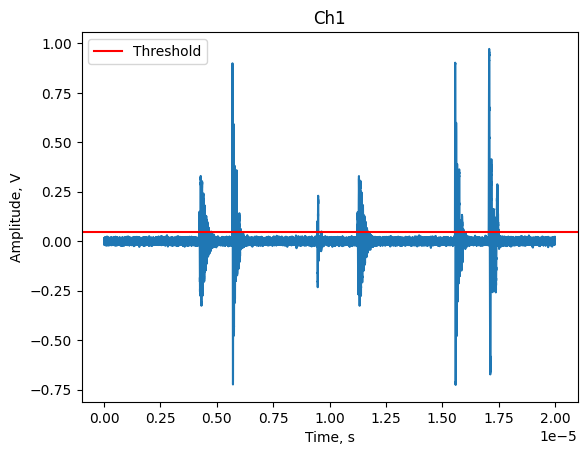

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Simulated_Waveforms/Ch1.csv", header = None)
plt.plot(df[0][0:100000], df[1][0:100000])
plt.axhline(y=0.048, color='r', linestyle='-', label = "Threshold")
plt.legend()
plt.title("Ch1")
plt.ylabel("Amplitude, V")
plt.xlabel("Time, s")
plt.show()

[0.0014009155259146807, 0.0006197808889855868, -0.013271967781817119, -0.01152821020767923, 0.03022487885827568, 0.0005834627461258068, -0.05456895843083407, 0.238760914607303, 0.717897082764412, 0.6173384491409358, 0.035272488035271894, -0.19155083129728512, -0.018233770779395985, 0.06207778930288603, 0.008859267493400484, -0.010264064027633142, -0.0004731544986800831, 0.0010694900329086053]
[-0.0010694900329086053, -0.0004731544986800831, 0.010264064027633142, 0.008859267493400484, -0.06207778930288603, -0.018233770779395985, 0.19155083129728512, 0.035272488035271894, -0.6173384491409358, 0.717897082764412, -0.238760914607303, -0.05456895843083407, -0.0005834627461258068, 0.03022487885827568, 0.01152821020767923, -0.013271967781817119, -0.0006197808889855868, 0.0014009155259146807]


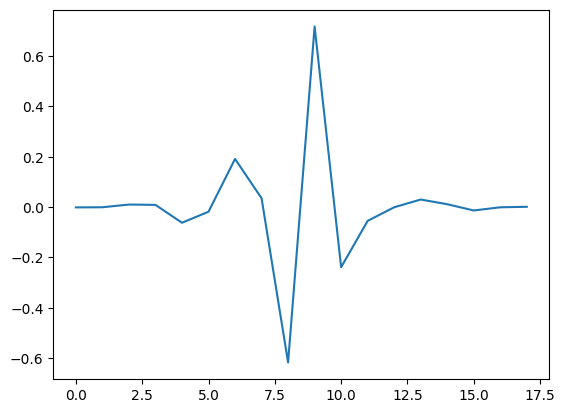

In [3]:
import pywt
from matplotlib import pyplot as plt
wavelet = pywt.Wavelet('sym9')

# Decomposition Low Pass (h)
print(wavelet.dec_lo) 

# Decomposition High Pass (g)
print(wavelet.dec_hi)

plt.plot(wavelet.dec_hi)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Data
sensors = {
    'Sensor 1': (1, 3, 1.4),
    'Sensor 2': (1, 5, 1.8),
    'Sensor 3': (1, 7, 1.4),
    'Sensor 4': (1, 9, 1.8)
}

pd_sources = {
    'PD1 (Void)': (3.7, 5, 0.1),
    'PD2 (Incision)': (3.7, 7, 0.1)
}

# Setup Plot
plt.figure(figsize=(10, 8))
plt.style.use('bmh') # Using a clean style

# Plot Sensors
sensor_x = [v[0] for v in sensors.values()]
sensor_y = [v[1] for v in sensors.values()]
plt.scatter(sensor_x, sensor_y, color='#2E86AB', s=200, marker='s', label='Sensors', edgecolors='black', zorder=3)

# Plot PD Sources
pd_x = [v[0] for v in pd_sources.values()]
pd_y = [v[1] for v in pd_sources.values()]
plt.scatter(pd_x, pd_y, color='#D62828', s=250, marker='*', label='PD Sources', edgecolors='black', zorder=3)

# Adding Labels
for name, (x, y, z) in sensors.items():
    plt.text(x - 0.1, y + 0.15, f"{name}\n({x}, {y}, {z})", fontsize=10, fontweight='bold', ha='right')

for name, (x, y, z) in pd_sources.items():
    plt.text(x + 0.1, y + 0.15, f"{name}\n({x}, {y}, {z})", fontsize=10, fontweight='bold', color='#D62828', ha='left')

# Formatting
plt.title('Experimental Layout (Top View)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('X (m)', fontsize=12)
plt.ylabel('Y (m)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right', frameon=True, shadow=True)

# Adjust limits for better padding
plt.xlim(0, 5)
plt.ylim(2, 10)

plt.tight_layout()
plt.savefig('experimental_layout_top_view.png', dpi=300)
plt.show()


In [8]:
import pandas as pd
import numpy as np

x = np.array(['a','b','a','c','a','b','a'])
df = pd.DataFrame(x, columns=['x'])

print(df.value_counts().idxmin()[0])


c
